# PERGAT Link Prediction for miRNA–Disease Associations

It loads the miRNA–disease graph, trains a graph attention network with five-fold edge cross-validation, exports scored cancer-related predictions, and renders the ROC and precision–recall curves inline.

## 1. Imports and paths

Load the project dependencies and locate this notebook’s data folder. The path lookup supports running Jupyter from the repository root, the `PERGAT` folder, or this notebook’s folder. Matplotlib is set to inline so plots render in the notebook.


In [25]:
%matplotlib inline
from pathlib import Path
from types import SimpleNamespace
import itertools
import json
import os
import sys

import dgl
import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
from IPython.display import Image, display
from matplotlib import pyplot as plt
from scipy.stats import sem
from sklearn.model_selection import KFold
from torch.optim.lr_scheduler import StepLR, ExponentialLR

current_dir = Path.cwd().resolve()
project_candidates = [
    current_dir,
    current_dir / 'link_prediction_gat_before_adding_plots',
    current_dir / 'PERGAT' / 'link_prediction_gat_before_adding_plots',
]
PROJECT_DIR = next(
    (path for path in project_candidates if (path / 'data' / 'miRNA_disease_network.json').exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        'Could not locate link_prediction_gat_before_adding_plots/data/miRNA_disease_network.json. '
        'Open this notebook from the repository or PERGAT folder.'
    )

DATA_DIR = PROJECT_DIR / 'data'
RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR))

from src.models import GATModel, MLPPredictor, FocalLoss
from src.utils import (
    plot_roc_curves,
    plot_pr_curves,
    plot_precision_recall_curves,
    compute_hits_k,
    compute_auc_with_symmetrical_confidence,
    compute_f1_with_symmetrical_confidence,
    compute_focalloss_with_symmetrical_confidence,
    compute_precision_with_symmetrical_confidence,
    compute_recall_with_symmetrical_confidence,
    compute_map_with_symmetrical_confidence,
    compute_accuracy_with_symmetrical_confidence,
)

print(f'Project folder: {PROJECT_DIR}')
print(f'Results folder: {RESULTS_DIR}')


Project folder: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/PERGAT/link_prediction_gat_before_adding_plots
Results folder: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/PERGAT/link_prediction_gat_before_adding_plots/results


## 2. Build the graph and node features

The JSON records become a directed DGL graph. Each node uses its stored 128-dimensional embedding; nodes without an embedding receive a zero vector, matching the original script.


In [26]:
def load_graph_data(file_path):
    # Load data from JSON file
    with open(file_path, 'r') as file:
        data = json.load(file)

    # Create a directed graph
    G_nx = nx.DiGraph()

    # Create a mapping for edge types to numerical values
    edge_type_mapping = {}

    # Node ID to name mapping
    node_id_to_name = {}
    node_counter = 0

    # Iterate over the data and add nodes and edges
    for item in data:
        source = item['miRNA']
        target = item['disease']
        relationship_type = item['relation']['type']

        # Extract source and target names
        source_name = source['properties']['name']
        target_name = target['properties']['name']

        if source_name not in G_nx:
            G_nx.add_node(source_name, **source['properties'])
            node_id_to_name[node_counter] = source_name
            node_counter += 1

        if target_name not in G_nx:
            G_nx.add_node(target_name, **target['properties'])
            node_id_to_name[node_counter] = target_name
            node_counter += 1

        # Add edge with numerical type
        if relationship_type not in edge_type_mapping:
            edge_type_mapping[relationship_type] = len(edge_type_mapping)
        G_nx.add_edge(source_name, target_name, type=edge_type_mapping[relationship_type])  

    # Check if all edges have the 'type' attribute and add default value if missing
    for u, v, data in G_nx.edges(data=True):
        if 'type' not in data:
            data['type'] = -1  # Assign a default value for missing 'type'

    # Convert the NetworkX graph to a DGL graph
    G_dgl = dgl.from_networkx(G_nx, edge_attrs=['type'])

    # Extract node features, ensuring 'embedding' exists for each node
    node_features = []
    for node in G_nx.nodes():
        if 'embedding' in G_nx.nodes[node]:
            node_features.append(G_nx.nodes[node]['embedding'])
        else:
            # Handle missing 'embedding' (use zero vector or other default value)
            node_features.append([0] * 128)  # Assuming embedding size is 128

    node_features = torch.tensor(node_features, dtype=torch.float32)
    G_dgl.ndata['feat'] = node_features

    return G_dgl, node_features, node_id_to_name


## 3. Load the miRNA–disease network

Inspect the graph size and feature matrix before training.


In [27]:
graph_path = DATA_DIR / 'miRNA_disease_network.json'
G_dgl, node_features, node_id_to_name = load_graph_data(graph_path)

print(f'Nodes: {G_dgl.number_of_nodes():,}')
print(f'Edges: {G_dgl.number_of_edges():,}')
print(f'Node feature shape: {tuple(node_features.shape)}')


Nodes: 8,977
Edges: 90,206
Node feature shape: (8977, 256)


## 4. Train and evaluate

In [28]:
def train_and_evaluate(args, G_dgl, node_features, node_id_to_name):
    u, v = G_dgl.edges()
    eids = np.arange(G_dgl.number_of_edges())
    adj = sp.coo_matrix((np.ones(len(u)), (u.numpy(), v.numpy())), shape=(G_dgl.number_of_nodes(), G_dgl.number_of_nodes()))
    adj_neg = 1 - adj.todense() - np.eye(G_dgl.number_of_nodes())
    neg_u, neg_v = np.where(adj_neg != 0)
    
    fold_results = []

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    output_path = str(RESULTS_DIR)
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(eids)):
        print(f'Fold {fold + 1}')
       
        val_size = int(len(train_idx) * 0.1)
        train_idx, val_idx = train_idx[val_size:], train_idx[:val_size]

        train_pos_u, train_pos_v = u[train_idx], v[train_idx]
        val_pos_u, val_pos_v = u[val_idx], v[val_idx]
        test_pos_u, test_pos_v = u[test_idx], v[test_idx]

        neg_eids = np.random.choice(len(neg_u), G_dgl.number_of_edges())
        train_neg_u, train_neg_v = neg_u[neg_eids[:len(train_idx)]], neg_v[neg_eids[:len(train_idx)]]
        val_neg_u, val_neg_v = neg_u[neg_eids[len(train_idx):len(train_idx) + len(val_idx)]], neg_v[neg_eids[len(train_idx):len(train_idx) + len(val_idx)]]
        test_neg_u, test_neg_v = neg_u[neg_eids[len(train_idx) + len(val_idx):]], neg_v[neg_eids[len(train_idx) + len(val_idx):]]

        train_g = dgl.remove_edges(G_dgl, test_idx.tolist() + val_idx.tolist())

        def create_graph(u, v, num_nodes):
            return dgl.graph((u, v), num_nodes=num_nodes)

        train_pos_g = create_graph(train_pos_u, train_pos_v, G_dgl.number_of_nodes())
        train_neg_g = create_graph(train_neg_u, train_neg_v, G_dgl.number_of_nodes())
        val_pos_g = create_graph(val_pos_u, val_pos_v, G_dgl.number_of_nodes())
        val_neg_g = create_graph(val_neg_u, val_neg_v, G_dgl.number_of_nodes())
        test_pos_g = create_graph(test_pos_u, test_pos_v, G_dgl.number_of_nodes())
        test_neg_g = create_graph(test_neg_u, test_neg_v, G_dgl.number_of_nodes())

        model = GATModel(
            node_features.shape[1],
            out_feats=args.out_feats,
            num_layers=args.num_layers,
            num_heads=args.num_heads,
            feat_drop=args.feat_drop,
            attn_drop=args.attn_drop,
            do_train=True
        )

        pred = MLPPredictor(args.input_size, args.hidden_size)
        criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean')
        optimizer = torch.optim.Adam(itertools.chain(model.parameters(), pred.parameters()), lr=args.lr)
        scheduler = StepLR(optimizer, step_size=1000, gamma=0.1)
        
        output_path_cross_roc = str(RESULTS_DIR / 'roc_curve_5_fold.png')
        output_path_cross_pr = str(RESULTS_DIR / 'pr_curve_5_fold.png')

        for e in range(args.epochs):
            model.train()
            h = model(train_g, train_g.ndata['feat'])
            pos_score = pred(train_pos_g, h)
            neg_score = pred(train_neg_g, h)

            pos_labels = torch.ones_like(pos_score)
            neg_labels = torch.zeros_like(neg_score)

            all_scores = torch.cat([pos_score, neg_score])
            all_labels = torch.cat([pos_labels, neg_labels])

            loss = criterion(all_scores, all_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if e % 5 == 0:
                print(f'Fold {fold + 1} | Epoch {e} | Loss: {loss.item()}')
        
        with torch.no_grad():
            model.eval()
            # h_test = model(G_dgl, G_dgl.ndata['feat'])
            h_test = model(train_g, train_g.ndata['feat'])
            test_pos_score = pred(test_pos_g, h_test)
            test_neg_score = pred(test_neg_g, h_test)
            test_auc, test_auc_err = compute_auc_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_f1, test_f1_err = compute_f1_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_focal_loss, test_focal_loss_err = compute_focalloss_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_precision, test_precision_err = compute_precision_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_recall, test_recall_err = compute_recall_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_hits_k = compute_hits_k(test_pos_score, test_neg_score, k=10)
            test_map, test_map_err = compute_map_with_symmetrical_confidence(test_pos_score, test_neg_score)
            test_accuracy, test_accuracy_err = compute_accuracy_with_symmetrical_confidence(test_pos_score, test_neg_score)

            print(f'Test AUC: {test_auc:.4f} ± {test_auc_err:.4f} | Test F1: {test_f1:.4f} ± {test_f1_err:.4f} | Test FocalLoss: {test_focal_loss:.4f} ± {test_focal_loss_err:.4f} | Test Accuracy: {test_accuracy:.4f} ± {test_accuracy_err:.4f} | Test Precision: {test_precision:.4f} ± {test_precision_err:.4f} | Test Recall: {test_recall:.4f} ± {test_recall_err:.4f} | Test Hits@10: {test_hits_k:.4f} | Test MAP: {test_map:.4f} ± {test_map_err:.4f}')

            # Prepare true labels and predicted scores
            true_labels = torch.cat([torch.ones(len(test_pos_score)), torch.zeros(len(test_neg_score))])
            predicted_scores = torch.cat([test_pos_score, test_neg_score]).cpu().numpy()

            fold_results.append((true_labels.cpu().numpy(), predicted_scores))
        
        # Save each fold's metrics and the ROC & PR curves
        os.makedirs(output_path, exist_ok=True)
        plot_roc_curves(fold_results, output_path_cross_roc)
        plot_pr_curves(fold_results, output_path_cross_pr)

    ##return fold_results

    
    top_predictions_u = []
    top_predictions_v = []
    for u, v, score in zip(test_pos_u, test_pos_v, test_pos_score):
        if 'rno-' in node_id_to_name[u.item()] or 'mmu-' in node_id_to_name[u.item()] or 'hsa-' in node_id_to_name[u.item()] or 'EBV-' in node_id_to_name[u.item()] or 'hcmv-' in node_id_to_name[u.item()] or 'mdv1-' in node_id_to_name[u.item()] or 'kshv-' in node_id_to_name[u.item()]:
            if ('cancer' in node_id_to_name[v.item()] or 'Cancer' in node_id_to_name[v.item()]) and 'rno-' not in node_id_to_name[v.item()] and 'mmu-' not in node_id_to_name[v.item()] and 'hsa-' not in node_id_to_name[v.item()] and 'EBV-' not in node_id_to_name[v.item()] and 'hcmv-' not in node_id_to_name[v.item()] and 'mdv1-' not in node_id_to_name[v.item()] and 'kshv-' not in node_id_to_name[v.item()]:
                top_predictions_u.append({
                    'source': node_id_to_name[u.item()],  # miRNA as source
                    'destination': node_id_to_name[v.item()],  # Disease as destination
                    'score': score.item()
                })
        elif 'rno-' in node_id_to_name[v.item()] or 'mmu-' in node_id_to_name[v.item()] or 'hsa-' in node_id_to_name[v.item()] or 'EBV-' in node_id_to_name[v.item()] or 'hcmv-' in node_id_to_name[v.item()] or 'mdv1-' in node_id_to_name[v.item()] or 'kshv-' in node_id_to_name[v.item()]:
            if ('cancer' in node_id_to_name[u.item()] or 'Cancer' in node_id_to_name[u.item()]) and 'rno-' not in node_id_to_name[u.item()] and 'mmu-' not in node_id_to_name[u.item()] and 'hsa-' not in node_id_to_name[u.item()] and 'EBV-' not in node_id_to_name[u.item()] and 'hcmv-' not in node_id_to_name[u.item()] and 'mdv1-' not in node_id_to_name[u.item()] and 'kshv-' not in node_id_to_name[u.item()]:
                top_predictions_v.append({
                    'source': node_id_to_name[u.item()],  # Disease as source
                    'destination': node_id_to_name[v.item()],  # miRNA as destination
                    'score': score.item()
                })

    top_predictions_u.sort(key=lambda x: x['score'], reverse=True)
    top_predictions_v.sort(key=lambda x: x['score'], reverse=True)
    top_predictions_u = top_predictions_u[:27061]
    top_predictions_v = top_predictions_v[:27061]

    df_top_u = pd.DataFrame(top_predictions_u)
    filename_u = f'top_scores_u_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.csv'
    df_top_u.to_csv(os.path.join(output_path, filename_u), index=False)

    df_top_v = pd.DataFrame(top_predictions_v)
    filename_v = f'top_scores_v_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.csv'
    df_top_v.to_csv(os.path.join(output_path, filename_v), index=False)

    ##print('test_size==========\n', test_size)

    file2 = DATA_DIR / 'merged_all_data.csv'
    filename_u_cancer = f'top_cancer_u_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.csv'

    df1 = pd.read_csv(os.path.join(output_path, filename_u))
    df2 = pd.read_csv(file2)

    # Merge the DataFrames based on 'miRNA' == 'source' and 'disease' == 'destination'
    merged_df = pd.merge(df2, df1, left_on=['miRNA', 'disease'], right_on=['source', 'destination'])

    # Display the rows with matching miRNA and disease with source and destination
    print(merged_df)

    # Optionally, save the matched rows to a new CSV file
    with open(os.path.join(output_path, filename_u_cancer), 'w') as f:
        merged_df.to_csv(f, index=False)

    # Apply the optional HMDD breast-cancer description filter when its CSV is available.
    description_path = DATA_DIR / 'hmdd_alldata_v4_updated.csv'
    if description_path.exists():
        df3 = pd.read_csv(description_path)
        breast_cancer_mirnas = df3.loc[
            df3['description'].str.contains('breast cancer', case=False, na=False), 'miRNA'
        ]
        filtered_df = df1[df1['source'].isin(breast_cancer_mirnas)]
        breast_cancer_rows = df2[
            df2['disease'].str.contains('breast cancer', case=False, na=False)
        ]
        merged_df_bc = pd.merge(breast_cancer_rows, filtered_df, left_on='miRNA', right_on='source')
        filename_breast_cancer = (
            f'top_breast_cancer_lr{args.lr}_lay{args.num_layers}_input{args.input_size}'
            f'_dim{args.out_feats}_epoch{args.epochs}.csv'
        )
        merged_df_bc.to_csv(os.path.join(output_path, filename_breast_cancer), index=False)
    else:
        print(f'Skipping breast-cancer description filter; file not found: {description_path}')

    '''filename_v_cancer = f'top_cancer_v_lr{args.lr}_lay{args.num_layers}_input{args.input_size}_dim{args.out_feats}_epoch{args.epochs}.csv'

    df1 = pd.read_csv(os.path.join(output_path, filename_v))
    df2 = pd.read_csv(file2)

    # Merge the DataFrames based on 'miRNA' == 'source' and 'disease' == 'destination'
    merged_df = pd.merge(df2, df1, left_on=['miRNA', 'disease'], right_on=['destination', 'source'])

    # Display the rows with matching miRNA and disease with source and destination
    print(merged_df)

    # Optionally, save the matched rows to a new CSV file
    with open(os.path.join(output_path, filename_v_cancer), 'w') as f:
        ##json.dump(test_results, f)
        merged_df.to_csv(f, index=False)'''
                


## 5. Configure and run training

These values match the script defaults. Lower `epochs` while iterating on the notebook, then restore the desired value for a full run.


In [29]:
args = SimpleNamespace(
    in_feats=256,
    out_feats=256,
    num_heads=1,
    num_layers=2,
    epochs=200,
    lr=0.01,
    input_size=2,
    hidden_size=16,
    feat_drop=0.0,
    attn_drop=0.0,
)

train_and_evaluate(args, G_dgl, node_features, node_id_to_name)


Fold 1
Fold 1 | Epoch 0 | Loss: 0.04298711568117142
Fold 1 | Epoch 5 | Loss: 0.019959906116127968
Fold 1 | Epoch 10 | Loss: 0.01635127142071724
Fold 1 | Epoch 15 | Loss: 0.01605537347495556
Fold 1 | Epoch 20 | Loss: 0.015859903767704964
Fold 1 | Epoch 25 | Loss: 0.015739552676677704
Fold 1 | Epoch 30 | Loss: 0.01568923518061638
Fold 1 | Epoch 35 | Loss: 0.01568109542131424
Fold 1 | Epoch 40 | Loss: 0.0156673863530159
Fold 1 | Epoch 45 | Loss: 0.015646442770957947
Fold 1 | Epoch 50 | Loss: 0.015639154240489006
Fold 1 | Epoch 55 | Loss: 0.01564004272222519
Fold 1 | Epoch 60 | Loss: 0.015633367002010345
Fold 1 | Epoch 65 | Loss: 0.015633095055818558
Fold 1 | Epoch 70 | Loss: 0.015630777925252914
Fold 1 | Epoch 75 | Loss: 0.015629880130290985
Fold 1 | Epoch 80 | Loss: 0.015628566965460777
Fold 1 | Epoch 85 | Loss: 0.01562761329114437
Fold 1 | Epoch 90 | Loss: 0.015628382563591003
Fold 1 | Epoch 95 | Loss: 0.015622273087501526
Fold 1 | Epoch 100 | Loss: 0.015777168795466423
Fold 1 | Epoch 1

## 6. Display the evaluation plots

The training helpers save and close their Matplotlib figures. This cell loads those saved PNGs as notebook output, so both curves appear inline after training completes.


ROC curve


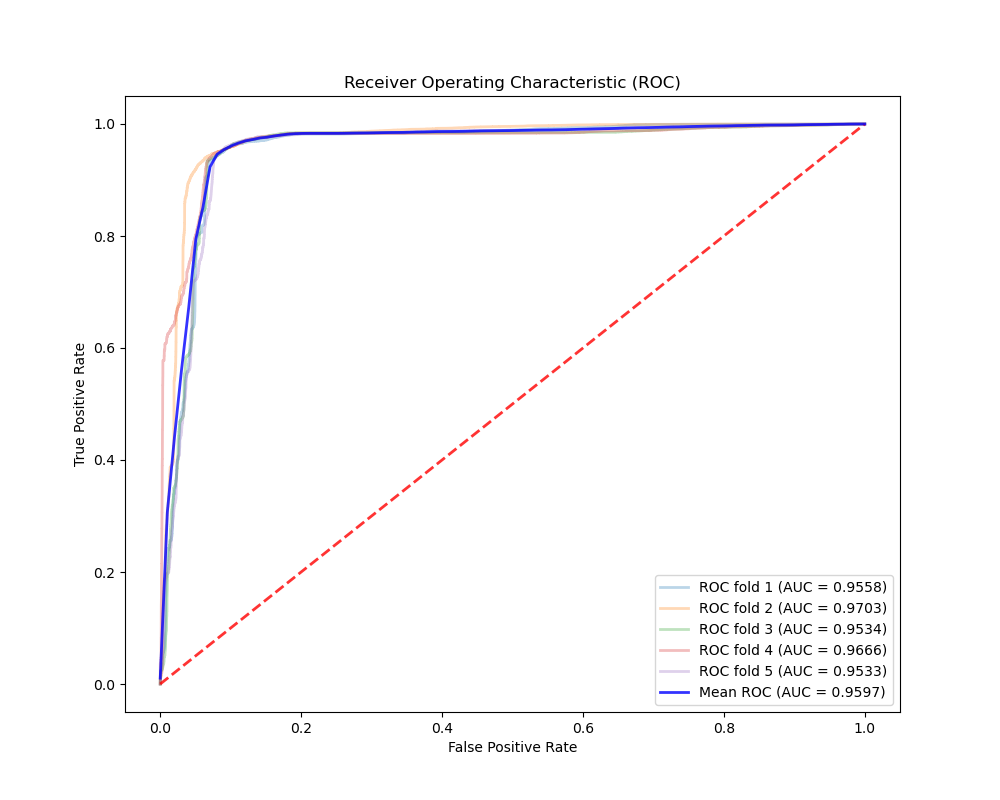

Precision–recall curve


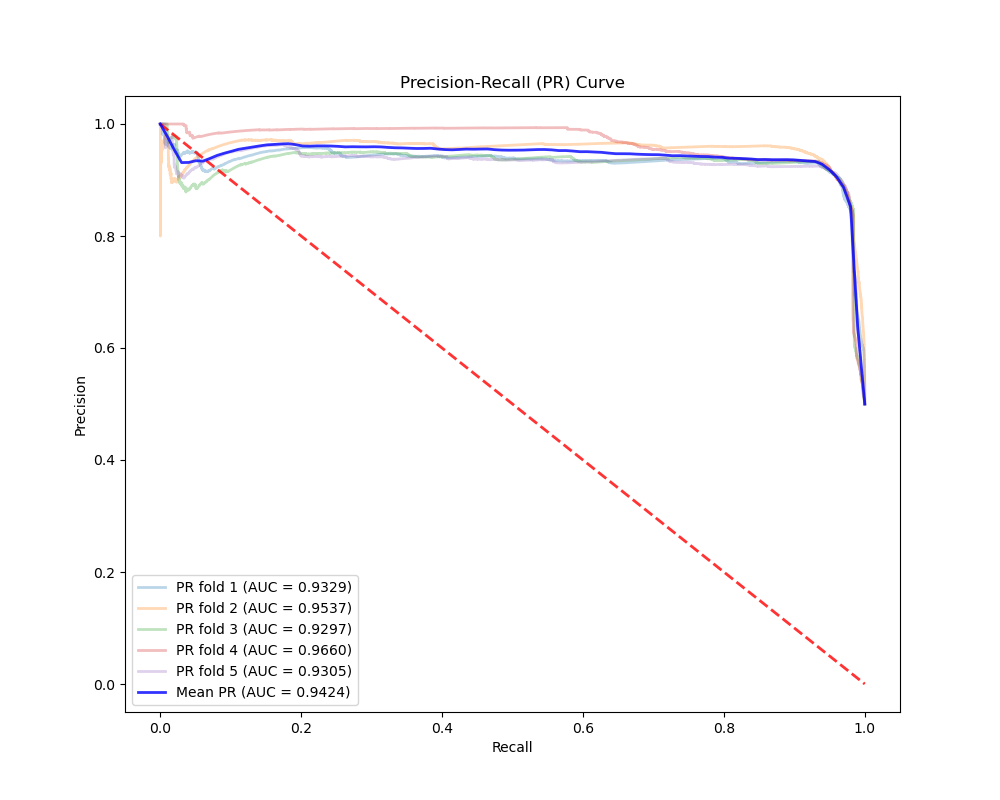

In [30]:
roc_path = RESULTS_DIR / 'roc_curve_5_fold.png'
pr_path = RESULTS_DIR / 'pr_curve_5_fold.png'

for title, image_path in [('ROC curve', roc_path), ('Precision–recall curve', pr_path)]:
    if image_path.exists():
        print(title)
        display(Image(filename=str(image_path)))
    else:
        print(f'{title} is not available yet: {image_path}')
